# 03 — Modelo Preditivo de Risco de Defasagem

## Objetivo

Desenvolver e avaliar um modelo de Machine Learning capaz de estimar
a probabilidade de um aluno apresentar defasagem no ano seguinte.

A estratégia utiliza validação temporal:

- Dados de 2022 → situação observada em 2023: treinamento
- Dados de 2023 → situação observada em 2024: teste

Essa abordagem evita misturar aleatoriamente passado e futuro e simula
melhor a utilização real do modelo.

In [2]:
# IMPORTAÇÕES E CONFIGURAÇÕES

from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)


# CAMINHOS

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

ARQUIVO = (
    ROOT /
    "data" /
    "processed" /
    "base_longitudinal.csv"
)

PASTA_MODELOS = ROOT / "models"
PASTA_TABELAS = ROOT / "outputs" / "tables"
PASTA_FIGURAS = ROOT / "outputs" / "figures"

PASTA_MODELOS.mkdir(parents=True, exist_ok=True)
PASTA_TABELAS.mkdir(parents=True, exist_ok=True)
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)


# CARREGAMENTO

base = pd.read_csv(ARQUIVO)


# GARANTE TIPOS NUMÉRICOS

colunas_numericas = [
    "fase_num",
    "idade",
    "ian",
    "ida",
    "ieg",
    "iaa",
    "ips",
    "ipv",
    "inde",
    "defasagem",
    "risco_prox_ano"
]

for coluna in colunas_numericas:
    base[coluna] = pd.to_numeric(
        base[coluna],
        errors="coerce"
    )


# FEATURES

# Usaremos apenas informações disponíveis no ano atual.
#
# anos_na_pm foi removida porque identificamos inconsistência
# longitudinal no campo ano_ingresso.
#
# IPP também não entra no modelo principal porque não está
# disponível de forma equivalente em 2022.

features = [
    "fase_num",
    "idade",
    "ian",
    "ida",
    "ieg",
    "iaa",
    "ips",
    "ipv",
    "inde",
    "defasagem"
]


# DIVISÃO TEMPORAL

# TREINO:
# informações de 2022
# para prever a situação observada em 2023

treino = base[
    (base["ano"] == 2022) &
    (base["risco_prox_ano"].notna())
].copy()


# TESTE:
# informações de 2023
# para prever a situação observada em 2024

teste = base[
    (base["ano"] == 2023) &
    (base["risco_prox_ano"].notna())
].copy()


X_train = treino[features]

y_train = (
    treino["risco_prox_ano"]
    .astype(int)
)

X_test = teste[features]

y_test = (
    teste["risco_prox_ano"]
    .astype(int)
)


# VALIDAÇÃO DAS AMOSTRAS

print("=" * 70)
print("MODELAGEM PREDITIVA — PREPARAÇÃO DOS DADOS")
print("=" * 70)

print(
    f"\nTreino — 2022 → 2023: "
    f"{len(X_train)} alunos"
)

print(
    f"Teste — 2023 → 2024: "
    f"{len(X_test)} alunos"
)


# DISTRIBUIÇÃO DO TARGET

print("\nDistribuição do TARGET no treino:")

dist_treino = (
    y_train
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Sem defasagem",
        1: "Com defasagem"
    })
)

display(
    dist_treino.to_frame(
        "alunos"
    )
)


print("\nPercentual no treino:")

display(
    (
        y_train
        .value_counts(
            normalize=True
        )
        .sort_index()
        .mul(100)
        .round(2)
        .rename(index={
            0: "Sem defasagem",
            1: "Com defasagem"
        })
        .to_frame("percentual")
    )
)


print("\nDistribuição do TARGET no teste:")

dist_teste = (
    y_test
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Sem defasagem",
        1: "Com defasagem"
    })
)

display(
    dist_teste.to_frame(
        "alunos"
    )
)


print("\nPercentual no teste:")

display(
    (
        y_test
        .value_counts(
            normalize=True
        )
        .sort_index()
        .mul(100)
        .round(2)
        .rename(index={
            0: "Sem defasagem",
            1: "Com defasagem"
        })
        .to_frame("percentual")
    )
)


# DADOS AUSENTES NAS FEATURES

print("\nDados ausentes nas features — TREINO:")

missing_train = (
    X_train
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(
        ascending=False
    )
)

display(
    missing_train.to_frame(
        "ausentes_%"
    )
)


print("\nDados ausentes nas features — TESTE:")

missing_test = (
    X_test
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(
        ascending=False
    )
)

display(
    missing_test.to_frame(
        "ausentes_%"
    )
)

MODELAGEM PREDITIVA — PREPARAÇÃO DOS DADOS

Treino — 2022 → 2023: 600 alunos
Teste — 2023 → 2024: 765 alunos

Distribuição do TARGET no treino:


,alunos
risco_prox_ano,
Sem defasagem,234
Com defasagem,366



Percentual no treino:


,percentual
risco_prox_ano,
Sem defasagem,39.0
Com defasagem,61.0



Distribuição do TARGET no teste:


...

,percentual
risco_prox_ano,
Sem defasagem,59.74
Com defasagem,40.26



Dados ausentes nas features — TREINO:


,ausentes_%
fase_num,0.0
idade,0.0
ian,0.0
ida,0.0
ieg,0.0
iaa,0.0
ips,0.0
ipv,0.0
inde,0.0
defasagem,0.0



Dados ausentes nas features — TESTE:


,ausentes_%
idade,39.74
inde,9.80
ipv,9.41
ida,9.41
ieg,9.41
ips,8.10
iaa,7.71
fase_num,0.00
ian,0.00
defasagem,0.00


In [3]:
# MODELO 1 — REGRESSÃO LOGÍSTICA

logistica = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])


# MODELO 2 — RANDOM FOREST

random_forest = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42
        )
    )
])


modelos = {
    "Regressão Logística":
        logistica,

    "Random Forest":
        random_forest
}


# AVALIAÇÃO

resultados = []

modelos_treinados = {}

for nome, modelo in modelos.items():

    modelo.fit(
        X_train,
        y_train
    )

    pred = modelo.predict(
        X_test
    )

    prob = modelo.predict_proba(
        X_test
    )[:, 1]

    metricas = {
        "modelo": nome,

        "accuracy":
            accuracy_score(
                y_test,
                pred
            ),

        "precision":
            precision_score(
                y_test,
                pred
            ),

        "recall":
            recall_score(
                y_test,
                pred
            ),

        "f1":
            f1_score(
                y_test,
                pred
            ),

        "roc_auc":
            roc_auc_score(
                y_test,
                prob
            ),

        "pr_auc":
            average_precision_score(
                y_test,
                prob
            )
    }

    resultados.append(metricas)

    modelos_treinados[nome] = modelo


resultados = pd.DataFrame(
    resultados
).sort_values(
    "roc_auc",
    ascending=False
)

display(resultados)

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Random Forest,0.783007,0.800847,0.613636,0.694853,0.870798,0.824068
0,Regressão Logística,0.728105,0.733645,0.509740,0.601533,0.808179,0.765523


In [5]:
# MODELO ESCOLHIDO

modelo_final = modelos_treinados[
    "Random Forest"
]

probabilidades = modelo_final.predict_proba(
    X_test
)[:, 1]


# TESTE DE DIFERENTES THRESHOLDS

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

comparacao_threshold = []

for threshold in thresholds:

    pred_threshold = (
        probabilidades >= threshold
    ).astype(int)

    comparacao_threshold.append({
        "threshold": threshold,

        "precision":
            precision_score(
                y_test,
                pred_threshold
            ),

        "recall":
            recall_score(
                y_test,
                pred_threshold
            ),

        "f1":
            f1_score(
                y_test,
                pred_threshold
            )
    })

comparacao_threshold = pd.DataFrame(
    comparacao_threshold
)

display(comparacao_threshold)


# IMPORTÂNCIA DAS FEATURES

modelo_rf = (
    modelo_final.named_steps["modelo"]
)

importancias = pd.DataFrame({
    "feature": features,
    "importancia":
        modelo_rf.feature_importances_
}).sort_values(
    "importancia",
    ascending=False
)

display(importancias)


# SALVA O MODELO

joblib.dump(
    modelo_final,
    PASTA_MODELOS /
    "modelo_risco.joblib"
)


# METADADOS

metadata = {
    "features": features,
    "target":
        "risco_prox_ano",

    "periodo_treino":
        "2022 -> 2023",

    "periodo_teste":
        "2023 -> 2024",

    "threshold":
        0.35,

    "descricao":
        "Probabilidade de defasagem no ano seguinte."
}

with open(
    PASTA_MODELOS /
    "metadata_modelo.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        metadata,
        arquivo,
        ensure_ascii=False,
        indent=4
    )


print("Modelo salvo com sucesso.")

,threshold,precision,recall,f1
0,0.30,0.628235,0.866883,0.728513
1,0.35,0.677596,0.805195,0.735905
2,0.40,0.713396,0.743506,0.728140
3,0.45,0.764259,0.652597,0.704028
4,0.50,0.800847,0.613636,0.694853


,feature,importancia
9,defasagem,0.185464
7,ipv,0.146370
8,inde,0.134984
0,fase_num,0.111752
1,idade,0.110899
2,ian,0.106495
3,ida,0.073813
4,ieg,0.069422
5,iaa,0.036820
6,ips,0.023980


Modelo salvo com sucesso.


MODELO FINAL — RANDOM FOREST
threshold   : 0.35
accuracy    : 0.767
precision   : 0.678
recall      : 0.805
f1          : 0.736
roc_auc     : 0.871
pr_auc      : 0.824

Matriz de confusão:
Verdadeiros negativos : 339
Falsos positivos      : 118
Falsos negativos      : 60
Verdadeiros positivos : 248


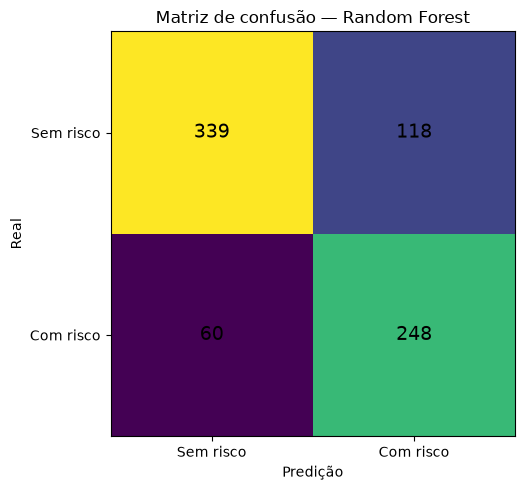


✅ Avaliação final concluída.


In [6]:
# AVALIAÇÃO FINAL — THRESHOLD ESCOLHIDO

THRESHOLD_FINAL = 0.35

probabilidades = modelo_final.predict_proba(
    X_test
)[:, 1]

pred_final = (
    probabilidades >= THRESHOLD_FINAL
).astype(int)


# MÉTRICAS FINAIS

metricas_finais = {
    "threshold": THRESHOLD_FINAL,

    "accuracy":
        accuracy_score(
            y_test,
            pred_final
        ),

    "precision":
        precision_score(
            y_test,
            pred_final
        ),

    "recall":
        recall_score(
            y_test,
            pred_final
        ),

    "f1":
        f1_score(
            y_test,
            pred_final
        ),

    "roc_auc":
        roc_auc_score(
            y_test,
            probabilidades
        ),

    "pr_auc":
        average_precision_score(
            y_test,
            probabilidades
        )
}


print("=" * 70)
print("MODELO FINAL — RANDOM FOREST")
print("=" * 70)

for metrica, valor in metricas_finais.items():

    if metrica == "threshold":
        print(
            f"{metrica:12}: {valor:.2f}"
        )

    else:
        print(
            f"{metrica:12}: {valor:.3f}"
        )


# MATRIZ DE CONFUSÃO

cm = confusion_matrix(
    y_test,
    pred_final
)

tn, fp, fn, tp = cm.ravel()


print("\nMatriz de confusão:")

print(f"Verdadeiros negativos : {tn}")
print(f"Falsos positivos      : {fp}")
print(f"Falsos negativos      : {fn}")
print(f"Verdadeiros positivos : {tp}")


# GRÁFICO DA MATRIZ

fig, ax = plt.subplots(
    figsize=(6, 5)
)

imagem = ax.imshow(cm)

ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)

ax.set_xticklabels([
    "Sem risco",
    "Com risco"
])

ax.set_yticklabels([
    "Sem risco",
    "Com risco"
])

ax.set_xlabel(
    "Predição"
)

ax.set_ylabel(
    "Real"
)

ax.set_title(
    "Matriz de confusão — Random Forest"
)


for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )


plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS /
    "modelo_matriz_confusao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# EXPORTA AS MÉTRICAS

pd.DataFrame(
    [metricas_finais]
).to_csv(
    PASTA_TABELAS /
    "metricas_modelo_final.csv",
    index=False
)


print(
    "\n✅ Avaliação final concluída."
)